## Experiment No: 9
## Experiment Title: Density-Based Clustering using DBSCAN - Identifying Cluster Structure and Noise Points

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries Imported Successfully")

Libraries Imported Successfully


### Step 2: Generate the Dataset - Simulated City Ride-Pickup Locations

In [2]:
def make_hotspot(center, n, spread):
    return np.random.normal(loc=center, scale=spread, size=(n, 2))

hotspot_a = make_hotspot((2.0, 2.0), 180, 0.18)   # Dense downtown hotspot
hotspot_b = make_hotspot((6.5, 1.5), 140, 0.15)   # Dense business district hotspot
hotspot_c = make_hotspot((4.0, 6.0), 100, 0.22)   # Medium-density mall area
suburb    = make_hotspot((9.0, 7.0), 90, 0.55)    # Sparse suburban region
noise_pts = np.random.uniform(low=-1, high=11, size=(35, 2))  # Scattered one-off pickups

X  = np.vstack([hotspot_a, hotspot_b, hotspot_c, suburb, noise_pts])
df = pd.DataFrame(X, columns=["longitude_km", "latitude_km"])

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (545, 2)


,longitude_km,latitude_km
0,1.942606,1.711463
1,1.723661,1.897328
2,1.960989,2.045877
3,1.973099,2.361941
4,1.982579,2.075996


### Step 3: Visualize the Raw Pickup Locations

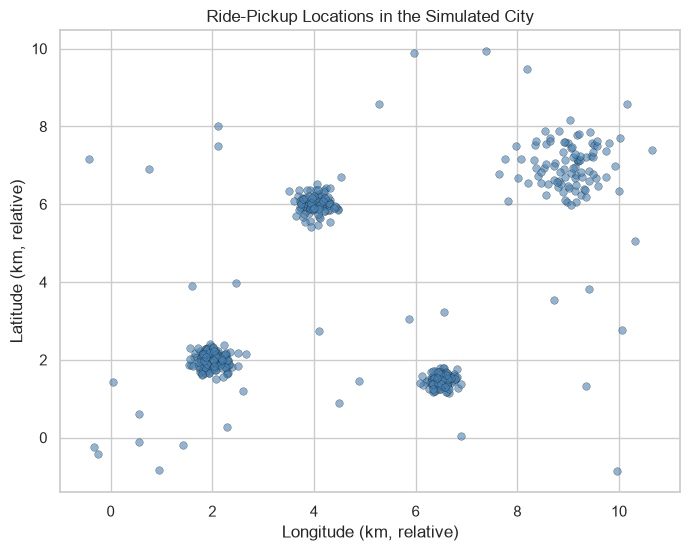

Notice the varying point density across regions, and scattered outlier points --
This is exactly the kind of structure DBSCAN is designed to detect.


In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(df["longitude_km"], df["latitude_km"], s=30, alpha=0.6, edgecolor="k", linewidth=0.3, color="steelblue")
plt.xlabel("Longitude (km, relative)")
plt.ylabel("Latitude (km, relative)")
plt.title("Ride-Pickup Locations in the Simulated City")
plt.show()


print("Notice the varying point density across regions, and scattered outlier points --")
print("This is exactly the kind of structure DBSCAN is designed to detect.")

### Step 4: Feature Scaling

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[["longitude_km", "latitude_km"]])

print("Features scaled successfully. Mean:", X_scaled.mean(axis=0), "Std Dev:", X_scaled.std(axis=0))

Features scaled successfully. Mean: [ 1.56449777e-16 -5.21499256e-17] Std Dev: [1. 1.]


### Step 5: Find a Suitable 'eps' Value using K-Distance Graph


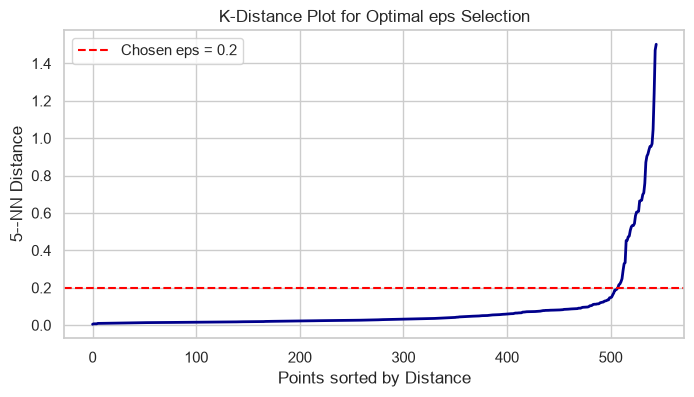

In [6]:
k  = 5 
nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)

distances, _     = nn.kneighbors(X_scaled)
sorted_distances = np.sort(distances[:, k - 1])

plt.figure(figsize=(8, 4))
plt.plot(sorted_distances, color="darkblue", linewidth=2)
plt.axhline(y=0.2, color="red", linestyle="--", label="Chosen eps = 0.2")
plt.xlabel("Points sorted by Distance")
plt.ylabel(f"{k}--NN Distance")
plt.title("K-Distance Plot for Optimal eps Selection")
plt.legend()
plt.show()

### Step 6: Apply DBSCAN on the Pickup Dataset

In [7]:
dbscan         = DBSCAN(eps=0.2, min_samples=5)
cluster_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = list(cluster_labels).count(-1)

print(f"DBSCAN found {n_clusters} clusters and identified {n_noise} noise points.")

DBSCAN found 4 clusters and identified 34 noise points.


### Step 7: Visualize DBSCAN Clustering Result

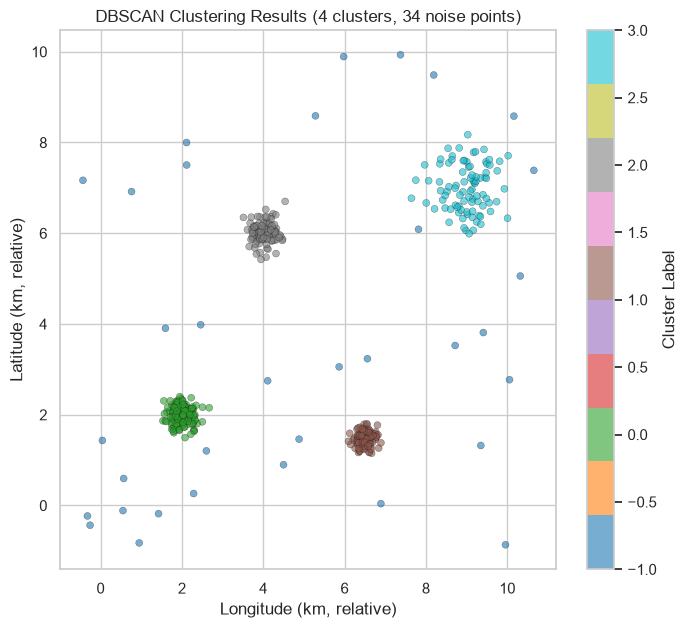

In [13]:
plt.figure(figsize=(8, 7))
scatter = plt.scatter(df["longitude_km"], df["latitude_km"], c=cluster_labels, cmap="tab10", s=25, alpha=0.6, edgecolor="k", linewidth=0.3)
plt.xlabel("Longitude (km, relative)")
plt.ylabel("Latitude (km, relative)")
plt.title(f"DBSCAN Clustering Results ({n_clusters} clusters, {n_noise} noise points)")
plt.colorbar(scatter, label="Cluster Label")
plt.show()

### Step 8: Demonstrate DBSCAN's Strength on Non-Globular Data (Moons Dataset)


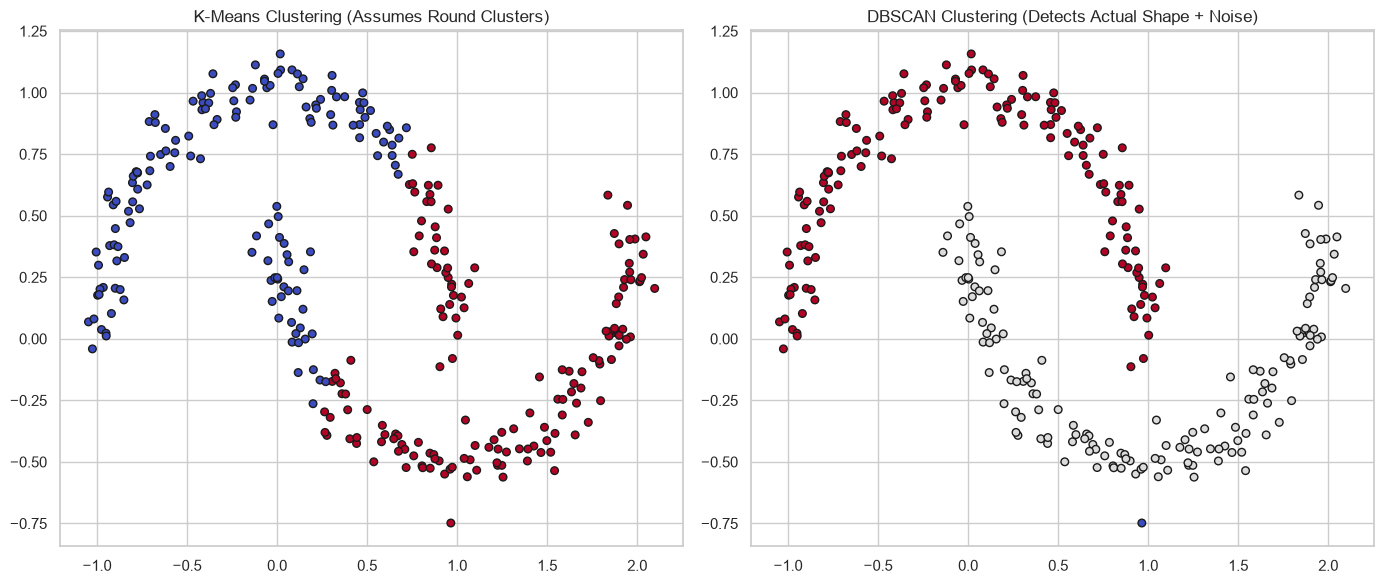

DBSCAN found 2 clusters
Noise points detected by DBSCAN: 1

Observation: K-Means splits the moon shapes incorrectly since it assumes round clusters.
DBSCAN correctly follows the curved density structure of the data.


In [17]:
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=300, noise=0.07, random_state=33)

dbscan_moons        = DBSCAN(eps=0.2, min_samples=5)
moons_labels_dbscan = dbscan_moons.fit_predict(X_moons)

kmeans_moons        = KMeans(n_clusters=2, n_init=10, random_state=33)
moons_labels_kmeans = kmeans_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=moons_labels_kmeans, cmap="coolwarm", s=30, edgecolor="k")
axes[0].set_title("K-Means Clustering (Assumes Round Clusters)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=moons_labels_dbscan, cmap="coolwarm", s=30, edgecolor="k")
axes[1].set_title("DBSCAN Clustering (Detects Actual Shape + Noise)")

plt.tight_layout()
plt.show()

n_noise_moons = list(moons_labels_dbscan).count(-1)
print(f"DBSCAN found {len(set(moons_labels_dbscan)) - (1 if -1 in moons_labels_dbscan else 0)} clusters")
print(f"Noise points detected by DBSCAN: {n_noise_moons}")
print("\nObservation: K-Means splits the moon shapes incorrectly since it assumes round clusters.")
print("DBSCAN correctly follows the curved density structure of the data.")

### Step 9: Evaluate Clustering Quality using Silhouette Score

In [18]:
mask = cluster_labels != -1
if len(set(cluster_labels[mask])) > 1:
    sil_score = silhouette_score(X_scaled[mask], cluster_labels[mask])
    print(f"Silhouette Score (Pickup Dataset, excluding noise): {sil_score:.4f}")
else:
    print("Not enough clusters (excluding noise) to compute silhouette score.")

Silhouette Score (Pickup Dataset, excluding noise): 0.9082


### Step 10: Final Output

In [19]:
print("Experiment Completed Successfully")
print(f"\nPickup Dataset -> Clusters found: {n_clusters}, Noise points: {n_noise}")
print(f"Moons Dataset  -> Clusters found: {len(set(moons_labels_dbscan)) - (1 if -1 in moons_labels_dbscan else 0)}, Noise points: {n_noise_moons}")

Experiment Completed Successfully

Pickup Dataset -> Clusters found: 4, Noise points: 34
Moons Dataset  -> Clusters found: 2, Noise points: 1
